In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Interenship\Online Retail.csv")

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 105202: invalid start byte

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Interenship\Online Retail.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [9]:
customer_data = df.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "Quantity": "sum"
})

customer_data.head()

,TotalPrice,Quantity
CustomerID,,
12346.0,0.00,0
12347.0,4310.00,2458
12348.0,1797.24,2341
12349.0,1757.55,631
12350.0,334.40,197


In [10]:
customer_data = customer_data.reset_index()

In [11]:
X = customer_data[["TotalPrice","Quantity"]]

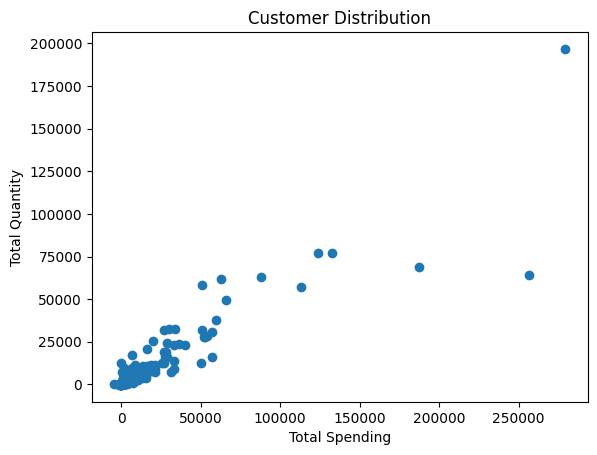

In [12]:
plt.scatter(customer_data["TotalPrice"], customer_data["Quantity"])
plt.xlabel("Total Spending")
plt.ylabel("Total Quantity")
plt.title("Customer Distribution")
plt.show()

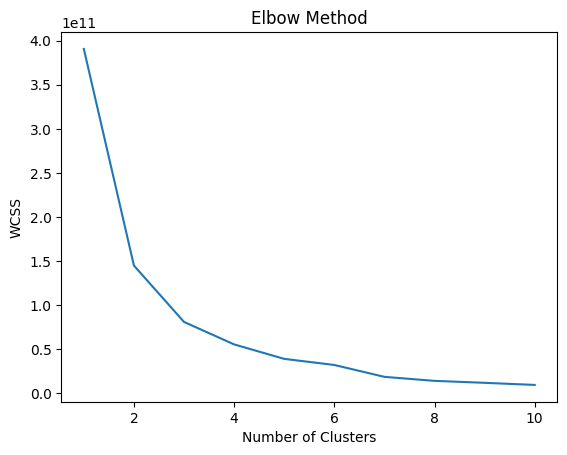

In [13]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)

customer_data["Cluster"] = kmeans.fit_predict(X)

customer_data.head()

,CustomerID,TotalPrice,Quantity,Cluster
0,12346.0,0.00,0,0
1,12347.0,4310.00,2458,0
2,12348.0,1797.24,2341,0
3,12349.0,1757.55,631,0
4,12350.0,334.40,197,0


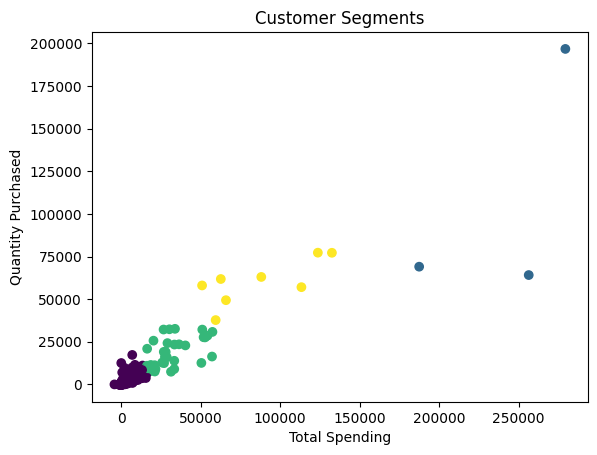

In [15]:
plt.scatter(
    customer_data["TotalPrice"],
    customer_data["Quantity"],
    c=customer_data["Cluster"]
)

plt.xlabel("Total Spending")
plt.ylabel("Quantity Purchased")
plt.title("Customer Segments")
plt.show()

In [16]:
customer_data.groupby("Cluster").mean()

,CustomerID,TotalPrice,Quantity
Cluster,,,
0,15302.021986,1319.18126,790.517473
1,16732.666667,241136.56000,109956.666667
2,15024.400000,29495.98400,16994.975000
3,14872.500000,87079.31875,60174.125000
